In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Loading the dataset
df = pd.read_csv('Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [ ]:
X = df.drop(columns=['price'])  # Dropping the target variable 'price' from the features
y = df['price']                 # Setting the target variable 'price'

original_df = df.copy(deep=True)  # Making deep copy of original dataframe to preserve it for later use

In [ ]:
#Checking the info of all the columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [ ]:
#Checking number of unique rows in each feature
df.nunique().sort_values()

guestroom             2
basement              2
mainroad              2
hotwaterheating       2
airconditioning       2
prefarea              2
furnishingstatus      3
bathrooms             4
parking               4
stories               4
bedrooms              6
price               219
area                284
dtype: int64

In [ ]:
# Numerical features
nf = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]

# Categorical features
cf = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

# Display the feature groups
print("\n\033[1mNumerical Features:\033[0m")
print(nf)

print("\n\033[1mCategorical Features:\033[0m")
print(cf)

print(
    "\n\033[1mInference:\033[0m "
    "The Dataset has {} numerical & {} categorical features."
    .format(len(nf), len(cf))
)


Numerical Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Categorical Features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Inference: The Dataset has 5 numerical & 7 categorical features.


In [ ]:
display(df.describe)

<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       

Text(0, 0.5, 'Frequency')

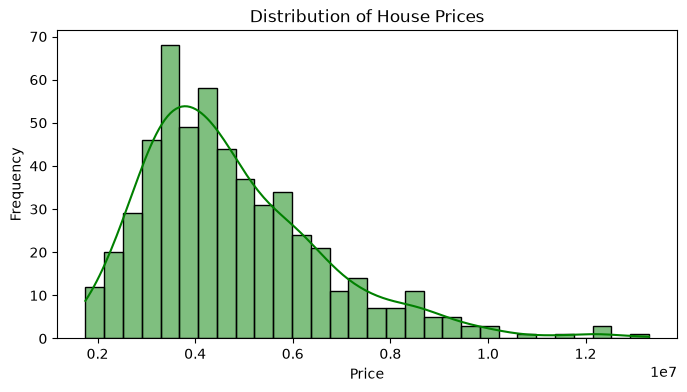

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

sns.histplot(
    df["price"],
    color="g",
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")


# This graph shows the relation between house prices and their frequency distribution

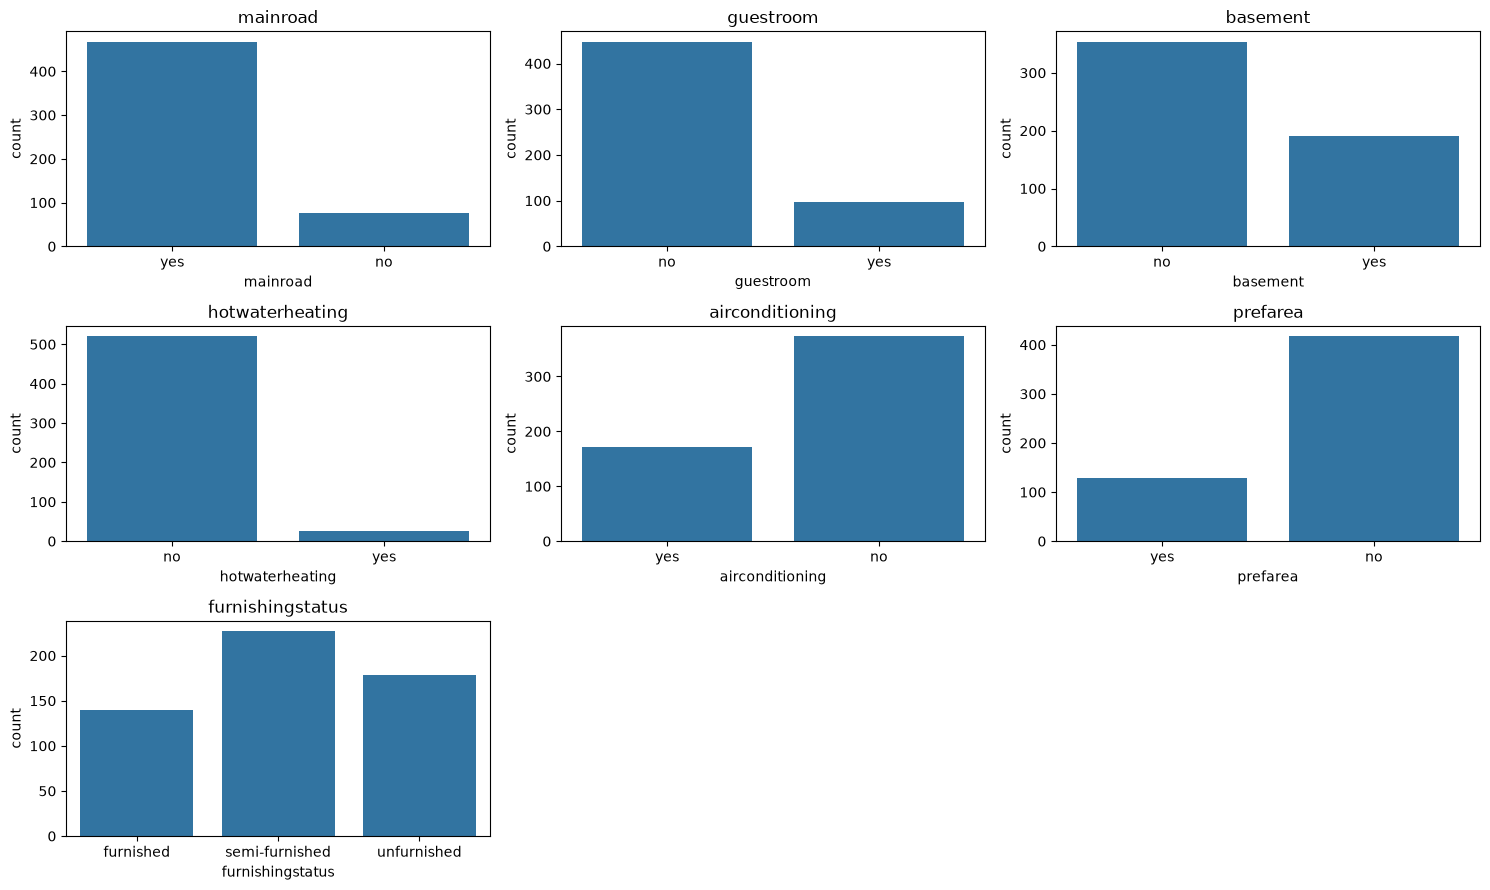

In [ ]:
import math

n = 3

rows = math.ceil(len(cf)/n)

plt.figure(figsize=(15,3* rows))

for i, feature in enumerate(cf):
    plt.subplot(rows,n,i+1)
    sns.countplot(x=feature, data=df)
    plt.title(feature)

plt.tight_layout()


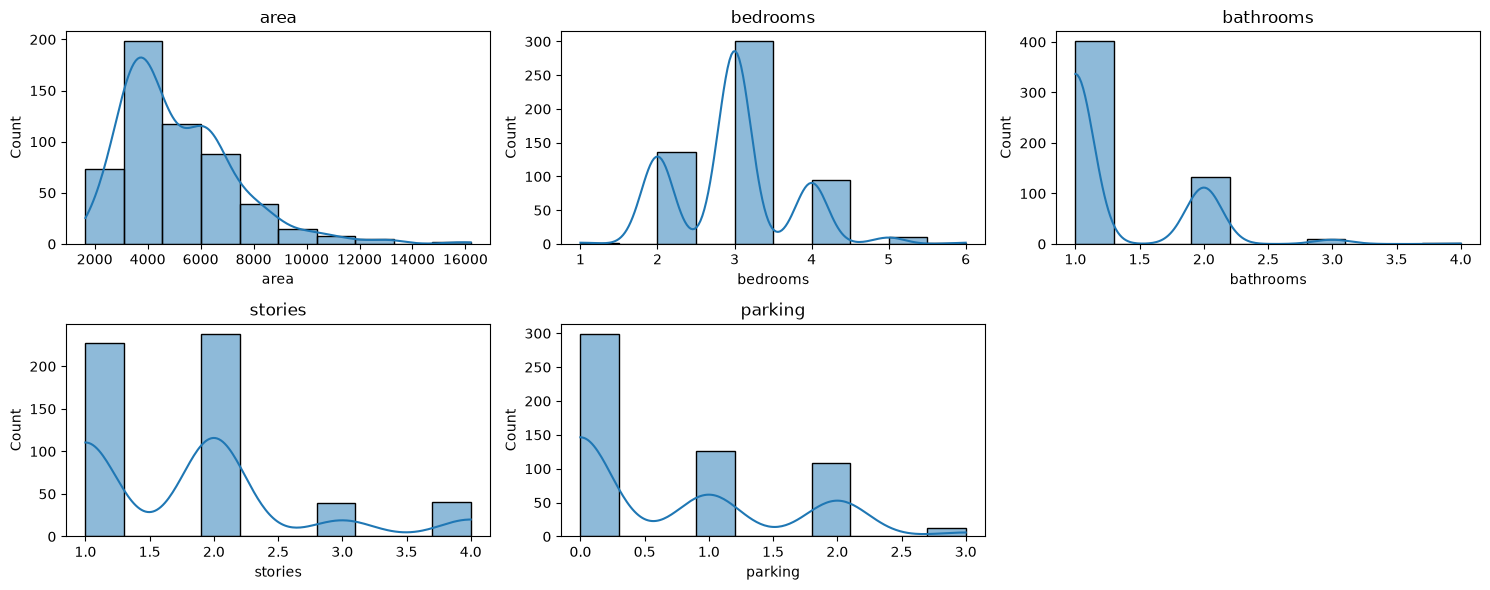

In [ ]:
n = 3
rows = math.ceil(len(nf) / n)

# Distribution plots
plt.figure(figsize=(15, 3 * rows))

for i, feature in enumerate(nf):
    plt.subplot(rows, n, i + 1)

    sns.histplot(
        df[feature],
        bins=10,
        kde=True
    )

    plt.title(feature)

plt.tight_layout()
plt.show()


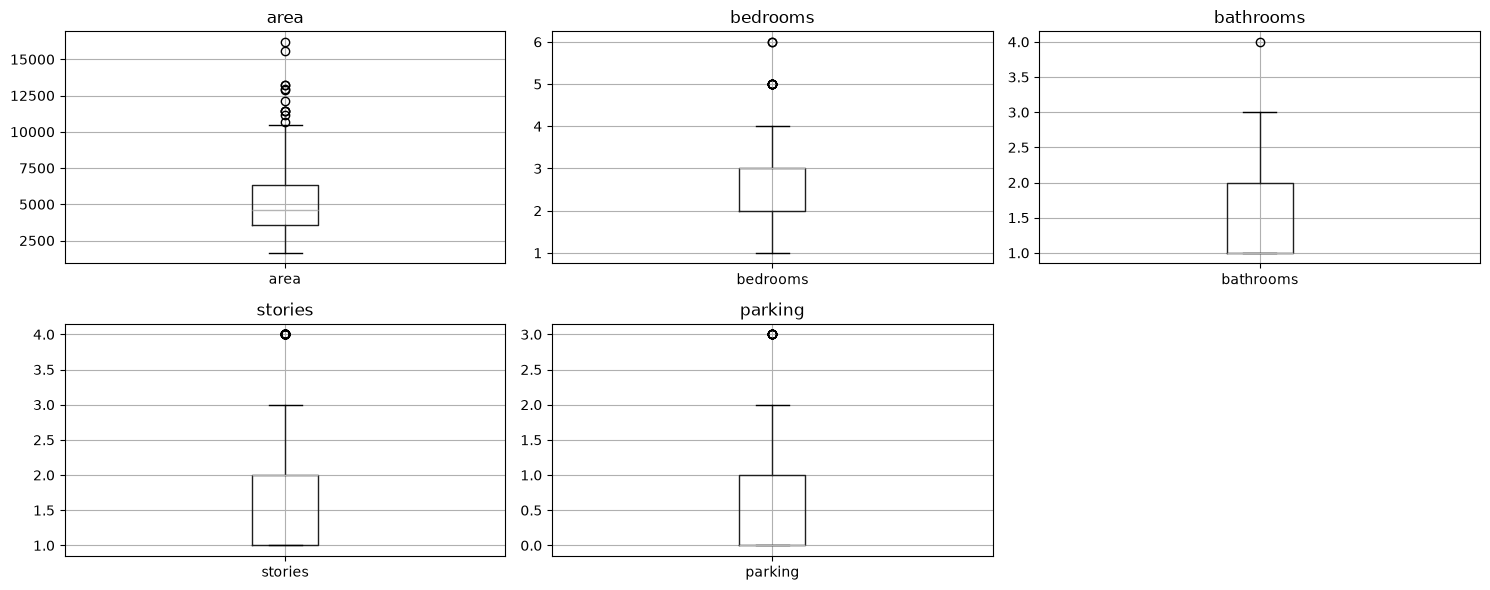

In [ ]:
# Boxplots
plt.figure(figsize=(15, 3 * rows))

for i, feature in enumerate(nf):
    plt.subplot(rows, n, i + 1)

    df.boxplot(column=feature)

    plt.title(feature)

plt.tight_layout()
plt.show()

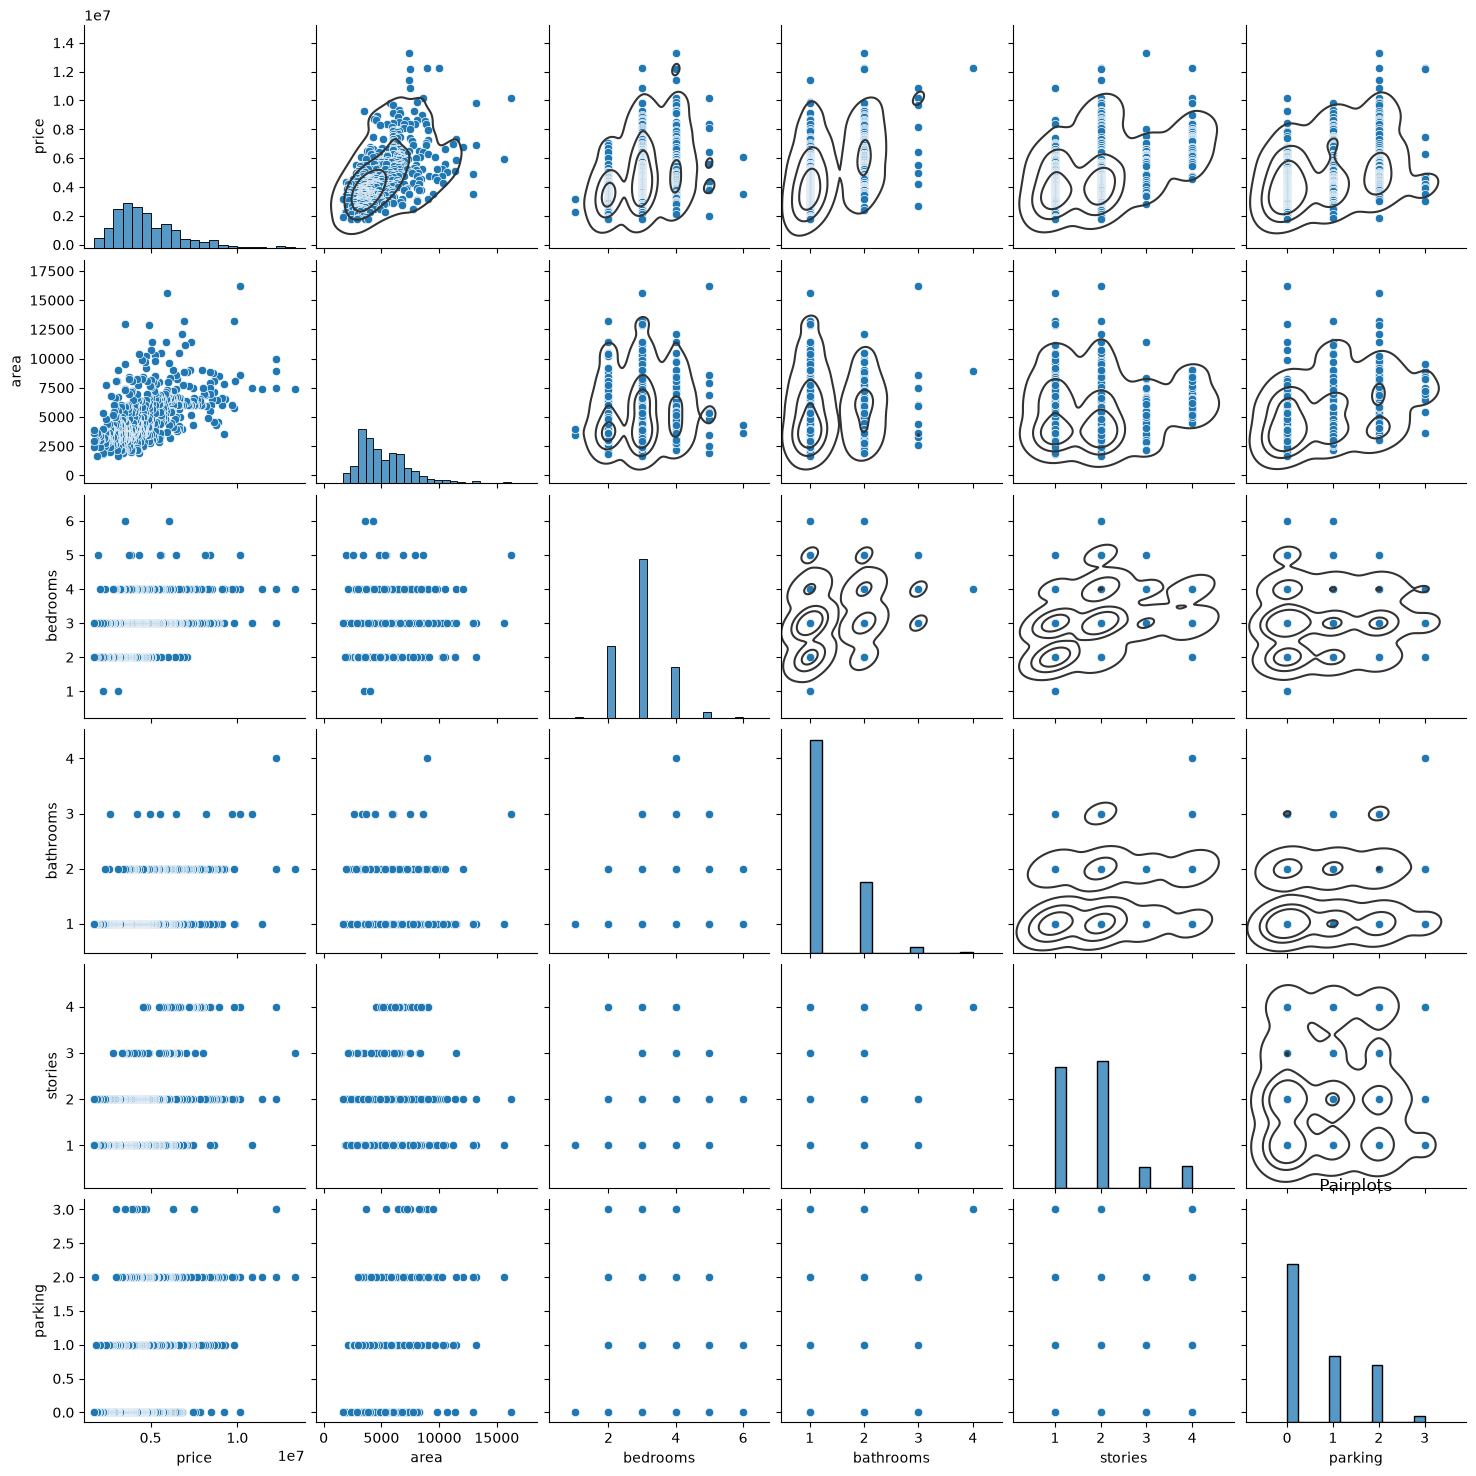

In [ ]:
g = sns.pairplot(df)
plt.title('Pairplots')
g.map_upper(sns.kdeplot, levels=4, color=".2")

In [ ]:
#Removal of any Duplicate rows (if any)

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows found: {duplicate_count}")

df.drop_duplicates(inplace=True)

print(f"Rows after removing duplicates: {df.shape[0]}")

Duplicate rows found: 0
Rows after removing duplicates: 545


In [ ]:
nvc = pd.DataFrame(df.isnull().sum().sort_values(), columns=['Total Null Values'])
nvc['Percentage'] = round(
    nvc['Total Null Values'] / df.shape[0] * 100,
    2
)
print(nvc)

                  Total Null Values  Percentage
price                             0         0.0
area                              0         0.0
bedrooms                          0         0.0
bathrooms                         0         0.0
stories                           0         0.0
mainroad                          0         0.0
guestroom                         0         0.0
basement                          0         0.0
hotwaterheating                   0         0.0
airconditioning                   0         0.0
parking                           0         0.0
prefarea                          0         0.0
furnishingstatus                  0         0.0


In [ ]:
df3 = df.copy()

# Binary categorical features → 0/1
binary_features = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for feature in binary_features:
    df3[feature] = pd.get_dummies(
        df3[feature],
        drop_first=True,
        dtype=int
    )

# furnishingstatus → dummy variables
df3 = pd.get_dummies(
    df3,
    columns=['furnishingstatus'],
    drop_first=True,
    dtype=int
)

print(df3.shape)

(545, 14)


In [ ]:
for feature in nf:
    Q1 = df3[feature].quantile(0.25)
    Q3 = df3[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df3[
        (df3[feature] < lower) |
        (df3[feature] > upper)
    ]

    print(f"{feature}: {len(outliers)} outliers")

area: 12 outliers
bedrooms: 12 outliers
bathrooms: 1 outliers
stories: 41 outliers
parking: 12 outliers


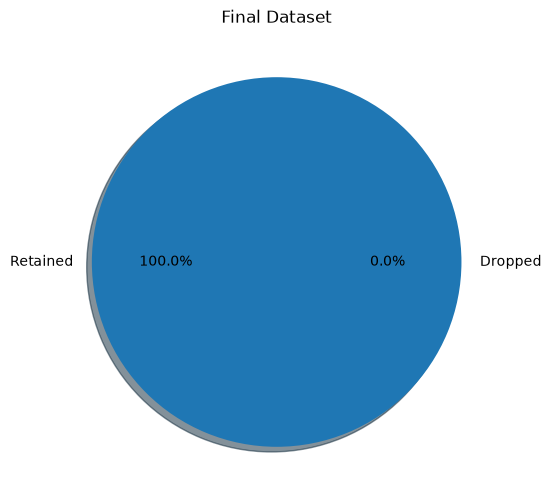


Inference: After preprocessing, 0 samples were dropped, while retaining 100.0% of the data.


In [ ]:
# Final Dataset size after preprocessing

df = df3.copy()

# Replace '-' with '_'
df.columns = [i.replace('-', '_') for i in df.columns]

retained = df.shape[0]
dropped = original_df.shape[0] - retained

plt.figure(figsize=(6, 6))

plt.pie(
    [retained, dropped],
    labels=['Retained', 'Dropped'],
    counterclock=False,
    autopct='%1.1f%%',
    shadow=True
)

plt.title('Final Dataset')

plt.show()

print(
    f'\n\033[1mInference:\033[0m '
    f'After preprocessing, {dropped} samples were dropped, '
    f'while retaining {round(retained * 100 / original_df.shape[0], 2)}% of the data.'
)

In [ ]:
from sklearn.model_selection import train_test_split


m  = []
for i in df.columns.values:
    m.append(i.replace(' ','_'))

df.columns = m
X = df.drop(["price"],axis=1)
Y = df["price"]

Train_X, Test_X, Train_Y, Test_Y = train_test_split(X, Y, train_size=0.8, test_size=0.2, random_state=100)
Train_X.reset_index(drop=True,inplace=True)

print('Original set  ---> ',X.shape,Y.shape,'\nTraining set  ---> ',Train_X.shape,Train_Y.shape,'\nTesting set   ---> ', Test_X.shape,'', Test_Y.shape)


Original set  --->  (545, 13) (545,) 
Training set  --->  (436, 13) (436,) 
Testing set   --->  (109, 13)  (109,)


In [ ]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

print('\033[1mStandardardization on Training set'.center(120))
Train_X_std = std.fit_transform(Train_X)
Train_X_std = pd.DataFrame(Train_X_std, columns=X.columns)
display(Train_X_std.describe())

print('\n','\033[1mStandardardization on Testing set'.center(120))
Test_X_std = std.transform(Test_X)
Test_X_std = pd.DataFrame(Test_X_std, columns=X.columns)
display(Test_X_std.describe())



                                         Standardardization on Training set                                         


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi_furnished,furnishingstatus_unfurnished
count,4.360000e+02,4.360000e+02,4.360000e+02,4.360000e+02,4.360000e+02,4.360000e+02,436.000000,4.360000e+02,4.360000e+02,4.360000e+02,4.360000e+02,4.360000e+02,4.360000e+02
mean,4.481634e-17,7.639149e-17,-1.201893e-16,9.370690e-17,-1.588943e-16,-8.148426e-18,0.000000,-4.481634e-17,4.787200e-17,-1.222264e-17,-5.296477e-17,-4.685345e-17,1.059295e-16
std,1.001149e+00,1.001149e+00,1.001149e+00,1.001149e+00,1.001149e+00,1.001149e+00,1.001149,1.001149e+00,1.001149e+00,1.001149e+00,1.001149e+00,1.001149e+00,1.001149e+00
min,-1.540198e+00,-2.665645e+00,-5.798966e-01,-9.290231e-01,-2.503331e+00,-4.558028e-01,-0.738985,-2.413554e-01,-6.553687e-01,-8.492607e-01,-5.490834e-01,-8.385255e-01,-6.986091e-01
25%,-7.389912e-01,-1.293483e+00,-5.798966e-01,-9.290231e-01,3.994677e-01,-4.558028e-01,-0.738985,-2.413554e-01,-6.553687e-01,-8.492607e-01,-5.490834e-01,-8.385255e-01,-6.986091e-01
50%,-2.933591e-01,7.867901e-02,-5.798966e-01,2.055821e-01,3.994677e-01,-4.558028e-01,-0.738985,-2.413554e-01,-6.553687e-01,-8.492607e-01,-5.490834e-01,-8.385255e-01,-6.986091e-01
75%,5.932510e-01,7.867901e-02,1.410929e+00,2.055821e-01,3.994677e-01,-4.558028e-01,1.353207,-2.413554e-01,1.525859e+00,3.114843e-01,-5.490834e-01,1.192570e+00,1.431416e+00
max,5.144981e+00,4.195165e+00,5.392582e+00,2.474792e+00,3.994677e-01,2.193931e+00,1.353207,4.143268e+00,1.525859e+00,2.632974e+00,1.821217e+00,1.192570e+00,1.431416e+00



                                          Standardardization on Testing set                                          


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi_furnished,furnishingstatus_unfurnished
count,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000
mean,0.012148,0.154211,-0.050227,-0.075467,-0.053262,0.079006,-0.028792,-0.201129,0.165093,-0.220968,0.038055,0.037268,-0.014656
std,1.049393,1.053562,1.000642,0.915477,1.058060,1.068435,0.995276,0.419971,1.061505,0.980508,1.027938,1.010532,0.999101
min,-1.626765,-1.293483,-0.579897,-0.929023,-2.503331,-0.455803,-0.738985,-0.241355,-0.655369,-0.849261,-0.549083,-0.838525,-0.698609
25%,-0.705249,0.078679,-0.579897,-0.929023,0.399468,-0.455803,-0.738985,-0.241355,-0.655369,-0.849261,-0.549083,-0.838525,-0.698609
50%,-0.090905,0.078679,-0.579897,0.205582,0.399468,-0.455803,-0.738985,-0.241355,-0.655369,-0.849261,-0.549083,-0.838525,-0.698609
75%,0.537402,1.450841,-0.579897,0.205582,0.399468,-0.455803,1.353207,-0.241355,1.525859,0.311484,-0.549083,1.192570,1.431416
max,4.865734,2.823003,3.401756,2.474792,0.399468,2.193931,1.353207,4.143268,1.525859,2.632974,1.821217,1.192570,1.431416


In [ ]:
#Checking the correlation

print('\033[1mCorrelation Matrix'.center(100))

plt.figure(figsize=[25,20])

sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, center=0) #cmap='BuGn'

plt.show()

                                       Correlation Matrix                                       


ValueError: could not convert string to float: 'yes'

<Figure size 2500x2000 with 0 Axes>

In [ ]:
# Testing a Linear Regression model with statsmodels

import statsmodels.formula.api as smf

# Combine standardized training features and training target
Train_xy = pd.concat(
    [Train_X_std, Train_Y.reset_index(drop=True)],
    axis=1
)

# Create the regression formula
formula = '{} ~ {}'.format(
    'price',
    ' + '.join(i for i in Train_X.columns)
)

print("Formula:", formula)

# Fit the OLS regression model
API = smf.ols(
    formula=formula,
    data=Train_xy
).fit()

# Display the statistical summary
API.summary()

Formula: price ~ area + bedrooms + bathrooms + stories + mainroad + guestroom + basement + hotwaterheating + airconditioning + parking + prefarea + furnishingstatus_semi_furnished + furnishingstatus_unfurnished


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     68.41
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           3.51e-95
Time:                        03:31:07   Log-Likelihood:                -6666.8
No. Observations:                 436   AIC:                         1.336e+04
Df Residuals:                     422   BIC:                         1.342e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                        4.796e+06   5.15e+04     93.111      0.000    4.69e+06     4.9e+06
area                             5.231e+05   5.95e+04      8.795      0.000    4.06e+05     6.4e+05
bedrooms                         6.612e+04   6.05e+04      1.093      0.275   -5.28e+04    1.85e+05
bathrooms                        5.713e+05   5.88e+04      9.710      0.000    4.56e+05    6.87e+05
stories                          3.577e+05   6.29e+04      5.687      0.000    2.34e+05    4.81e+05
mainroad                         1.981e+05   5.59e+04      3.545      0.000    8.83e+04    3.08e+05
guestroom                        1.453e+05   5.69e+04      2.555      0.011    3.35e+04    2.57e+05
basement                         1.327e+05   5.92e+04      2.241      0.026    1.63e+04    2.49e+05
hotwaterheating                  1.934e+05   5.29e+04      3.658      0.000    8.95e+04    2.97e+05
airconditioning                  3.874e+05   5.66e+04      6.844      0.000    2.76e+05    4.99e+05
parking                          2.084e+05   5.64e+04      3.693      0.000    9.75e+04    3.19e+05
prefarea                          2.55e+05   5.46e+04      4.667      0.000    1.48e+05    3.62e+05
furnishingstatus_semi_furnished -5.021e+04   6.48e+04     -0.775      0.439   -1.78e+05    7.71e+04
furnishingstatus_unfurnished    -2.006e+05   6.59e+04     -3.041      0.003    -3.3e+05   -7.09e+04
==============================================================================
Omnibus:                       79.435   Durbin-Watson:                   2.090
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              209.468
Skew:                           0.886   Prob(JB):                     3.27e-46
Kurtosis:                       5.897   Cond. No.                         2.50
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

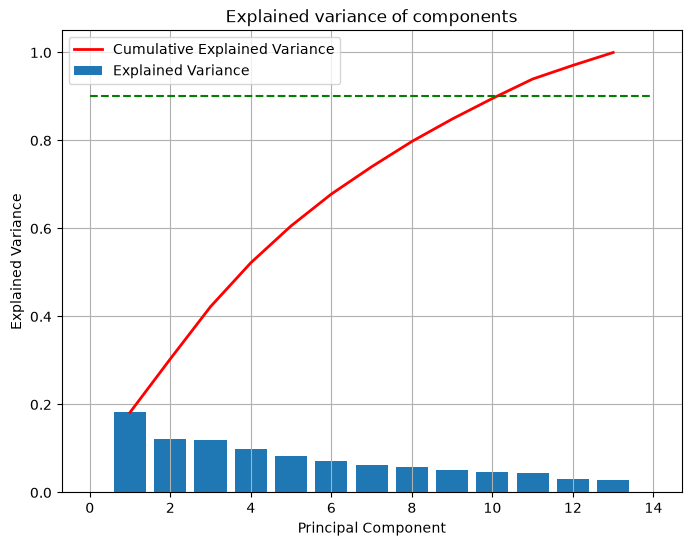

In [ ]:
from sklearn.decomposition import PCA

pca = PCA().fit(Train_X_std)

fig, ax = plt.subplots(figsize=(8,6))
x_values = range(1, pca.n_components_+1)
ax.bar(x_values, pca.explained_variance_ratio_, lw=2, label='Explained Variance')
ax.plot(x_values, np.cumsum(pca.explained_variance_ratio_), lw=2, label='Cumulative Explained Variance', color='red')
plt.plot([0,pca.n_components_+1],[0.9,0.9],'g--')
ax.set_title('Explained variance of components')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance')
plt.legend()
plt.grid()
plt.show()

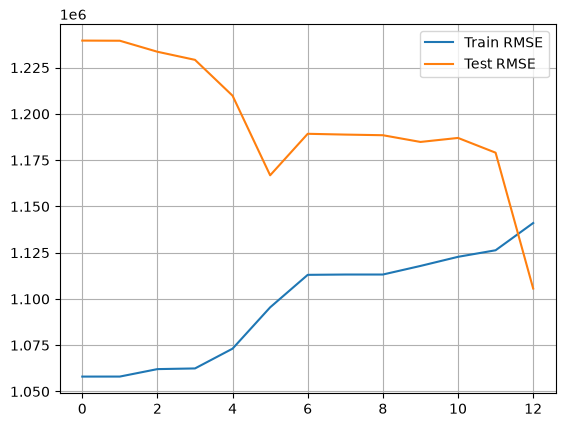

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Trr=[]; Tss=[]; 

m=df.shape[1]-1

for i in range(m):
    pca = PCA(n_components=Train_X_std.shape[1]-i)
    Train_X_std_pca = pca.fit_transform(Train_X_std)
    Test_X_std_pca = pca.fit_transform(Test_X_std)
    
    LR = LinearRegression()
    LR.fit(Train_X_std_pca, Train_Y)

    pred1 = LR.predict(Train_X_std_pca)
    pred2 = LR.predict(Test_X_std_pca)

    Trr.append(round(np.sqrt(mean_squared_error(Train_Y, pred1)),2))
    Tss.append(round(np.sqrt(mean_squared_error(Test_Y, pred2)),2))

plt.plot(Trr, label='Train RMSE')
plt.plot(Tss, label='Test RMSE')
#plt.ylim([19.5,20.75])
plt.legend()
plt.grid()
plt.show()

In [ ]:
# #Shortlisting the selected Features (with RFE)
from sklearn.feature_selection import RFE

lm = LinearRegression()
rfe = RFE(lm,n_features_to_select=Train_X_std.shape[1]-5)             # running RFE
rfe = rfe.fit(Train_X_std, Train_Y)

LR = LinearRegression()
LR.fit(Train_X_std.loc[:,rfe.support_], Train_Y)

pred1 = LR.predict(Train_X_std.loc[:,rfe.support_])
pred2 = LR.predict(Test_X_std.loc[:,rfe.support_])

print(np.sqrt(mean_squared_error(Train_Y, pred1)))
print(np.sqrt(mean_squared_error(Test_Y, pred2)))

1099279.2612122002
1122117.5513312188


In [ ]:
#Let us first define a function to evaluate our models

from sklearn.metrics import r2_score, mean_squared_error

Model_Evaluation_Comparison_Matrix = pd.DataFrame(np.zeros([5,8]), columns=['Train-R2','Test-R2','Train-RSS','Test-RSS',
                                                                            'Train-MSE','Test-MSE','Train-RMSE','Test-RMSE'])
rc=np.random.choice(Train_X_std.loc[:,Train_X_std.nunique()>=50].columns.values,1,replace=False)
def Evaluate(n, pred1,pred2):
    #Plotting predicted predicteds alongside the actual datapoints 
    plt.figure(figsize=[15,6])
    for e,i in enumerate(rc):
        plt.subplot(2,3,e+1)
        plt.scatter(y=Train_Y, x=Train_X_std[i], label='Actual')
        plt.scatter(y=pred1, x=Train_X_std[i], label='Prediction')
        plt.legend()
    plt.show()

    #Evaluating the Multiple Linear Regression Model

    print('\n\n{}Training Set Metrics{}'.format('-'*20, '-'*20))
    print('\nR2-Score on Training set --->',round(r2_score(Train_Y, pred1),20))
    print('Residual Sum of Squares (RSS) on Training set  --->',round(np.sum(np.square(Train_Y-pred1)),20))
    print('Mean Squared Error (MSE) on Training set       --->',round(mean_squared_error(Train_Y, pred1),20))
    print('Root Mean Squared Error (RMSE) on Training set --->',round(np.sqrt(mean_squared_error(Train_Y, pred1)),20))

    print('\n{}Testing Set Metrics{}'.format('-'*20, '-'*20))
    print('\nR2-Score on Testing set --->',round(r2_score(Test_Y, pred2),20))
    print('Residual Sum of Squares (RSS) on Training set  --->',round(np.sum(np.square(Test_Y-pred2)),20))
    print('Mean Squared Error (MSE) on Training set       --->',round(mean_squared_error(Test_Y, pred2),20))
    print('Root Mean Squared Error (RMSE) on Training set --->',round(np.sqrt(mean_squared_error(Test_Y, pred2)),20))
    print('\n{}Residual Plots{}'.format('-'*20, '-'*20))
    
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-R2']  = round(r2_score(Train_Y, pred1),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-R2']   = round(r2_score(Test_Y, pred2),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-RSS'] = round(np.sum(np.square(Train_Y-pred1)),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-RSS']  = round(np.sum(np.square(Test_Y-pred2)),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-MSE'] = round(mean_squared_error(Train_Y, pred1),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-MSE']  = round(mean_squared_error(Test_Y, pred2),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-RMSE']= round(np.sqrt(mean_squared_error(Train_Y, pred1)),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-RMSE'] = round(np.sqrt(mean_squared_error(Test_Y, pred2)),20)

    # Plotting y_test and y_pred to understand the spread.
    plt.figure(figsize=[15,4])

    plt.subplot(1,2,1)
    sns.distplot((Train_Y - pred1))
    plt.title('Error Terms')          
    plt.xlabel('Errors') 

    plt.subplot(1,2,2)
    plt.scatter(Train_Y,pred1)
    plt.plot([Train_Y.min(),Train_Y.max()],[Train_Y.min(),Train_Y.max()], 'r--')
    plt.title('Test vs Prediction')         
    plt.xlabel('y_test')                       
    plt.ylabel('y_pred')                       

<<<----------------------------------- Evaluating Multiple Linear Regression Model ----------------------------------->>>

The Coeffecient of the Regresion Model was found to be  [ 523109.95193922   66116.64775464  571341.38886287  357741.5667533
  198127.53395452  145258.91156324  132749.64195469  193370.1889252
  387432.17922426  208377.3327589   255018.10885467  -50208.88614929
 -200559.54373648]
The Intercept of the Regresion Model was found to be  4795729.220183486


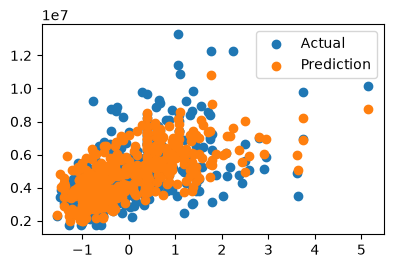



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.67817893928693
Residual Sum of Squares (RSS) on Training set  ---> 488093560627881.5
Mean Squared Error (MSE) on Training set       ---> 1119480643641.93
Root Mean Squared Error (RMSE) on Training set ---> 1058055.1231584912

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.6806539407870679
Residual Sum of Squares (RSS) on Training set  ---> 122856712931889.92
Mean Squared Error (MSE) on Training set       ---> 1127125806714.5867
Root Mean Squared Error (RMSE) on Training set ---> 1061661.8137215762

--------------------Residual Plots--------------------


C:\Users\piyus\AppData\Local\Temp\ipykernel_18200\2030384463.py:46: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((Train_Y - pred1))


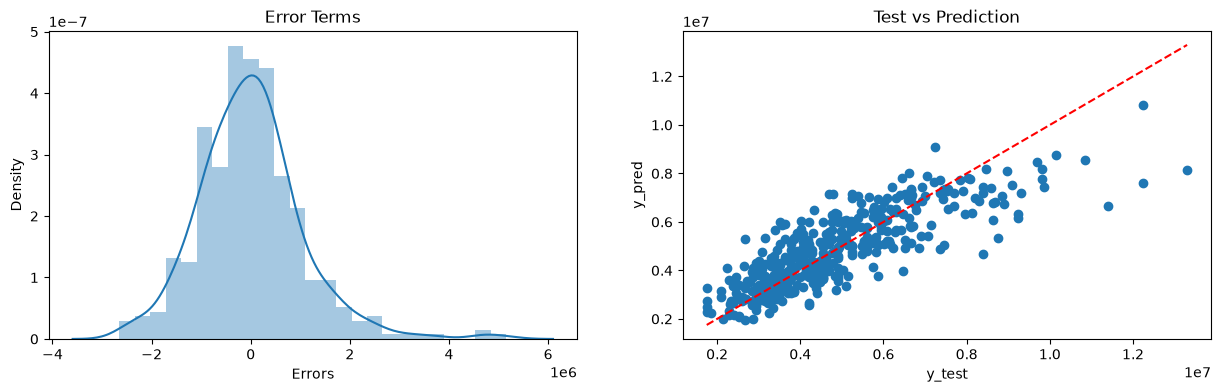

In [ ]:
#Linear Regression

MLR = LinearRegression().fit(Train_X_std,Train_Y)
pred1 = MLR.predict(Train_X_std)
pred2 = MLR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Multiple Linear Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(0, pred1, pred2)

<<<----------------------------------- Evaluating Ridge Regression Model ----------------------------------->>>

The Coeffecient of the Regresion Model was found to be  [ 523109.95193922   66116.64775464  571341.38886287  357741.5667533
  198127.53395452  145258.91156324  132749.64195469  193370.1889252
  387432.17922426  208377.3327589   255018.10885467  -50208.88614929
 -200559.54373648]
The Intercept of the Regresion Model was found to be  4795729.220183486


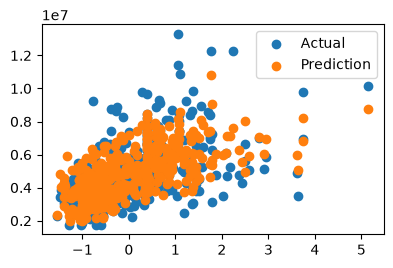



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.6781778595305621
Residual Sum of Squares (RSS) on Training set  ---> 488095198252619.44
Mean Squared Error (MSE) on Training set       ---> 1119484399661.9714
Root Mean Squared Error (RMSE) on Training set ---> 1058056.8981212548

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.6808112416462249
Residual Sum of Squares (RSS) on Training set  ---> 122796197181218.05
Mean Squared Error (MSE) on Training set       ---> 1126570616341.45
Root Mean Squared Error (RMSE) on Training set ---> 1061400.3091866188

--------------------Residual Plots--------------------


C:\Users\piyus\AppData\Local\Temp\ipykernel_18200\2030384463.py:46: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((Train_Y - pred1))


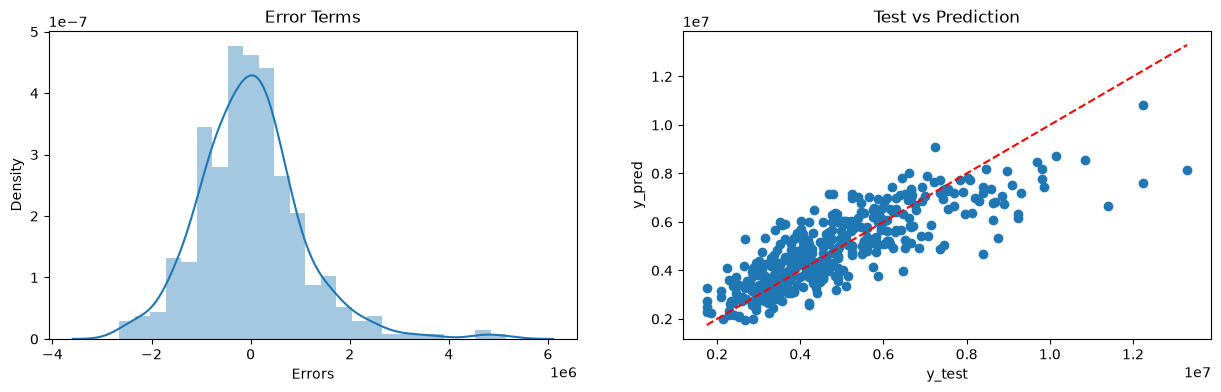

In [ ]:
#Creating a Ridge Regression model

from sklearn.linear_model import Ridge

RLR = Ridge().fit(Train_X_std,Train_Y)
pred1 = RLR.predict(Train_X_std)
pred2 = RLR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Ridge Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(1, pred1, pred2)

<<<----------------------------------- Evaluating Lasso Regression Model ----------------------------------->>>

The Coeffecient of the Regresion Model was found to be  [ 523109.95193922   66116.64775464  571341.38886287  357741.5667533
  198127.53395452  145258.91156324  132749.64195469  193370.1889252
  387432.17922426  208377.3327589   255018.10885467  -50208.88614929
 -200559.54373648]
The Intercept of the Regresion Model was found to be  4795729.220183486


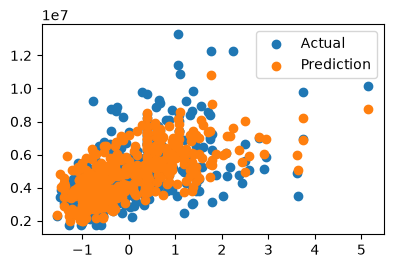



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.6781789392843383
Residual Sum of Squares (RSS) on Training set  ---> 488093560631812.3
Mean Squared Error (MSE) on Training set       ---> 1119480643650.9456
Root Mean Squared Error (RMSE) on Training set ---> 1058055.1231627516

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.6806540572679426
Residual Sum of Squares (RSS) on Training set  ---> 122856668120134.86
Mean Squared Error (MSE) on Training set       ---> 1127125395597.5676
Root Mean Squared Error (RMSE) on Training set ---> 1061661.6201019832

--------------------Residual Plots--------------------


C:\Users\piyus\AppData\Local\Temp\ipykernel_18200\2030384463.py:46: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((Train_Y - pred1))


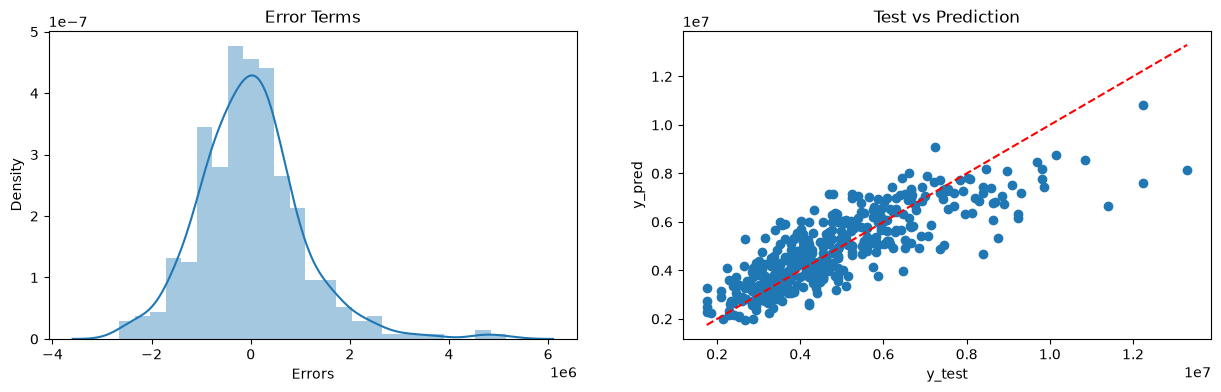

In [ ]:
#Creating a Ridge Regression model

from sklearn.linear_model import Lasso

LLR = Lasso().fit(Train_X_std,Train_Y)
pred1 = LLR.predict(Train_X_std)
pred2 = LLR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Lasso Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(2, pred1, pred2)

<<<----------------------------------- Evaluating Elastic-Net Regression Model ----------------------------------->>>

The Coeffecient of the Regresion Model was found to be  [ 523109.95193922   66116.64775464  571341.38886287  357741.5667533
  198127.53395452  145258.91156324  132749.64195469  193370.1889252
  387432.17922426  208377.3327589   255018.10885467  -50208.88614929
 -200559.54373648]
The Intercept of the Regresion Model was found to be  4795729.220183486


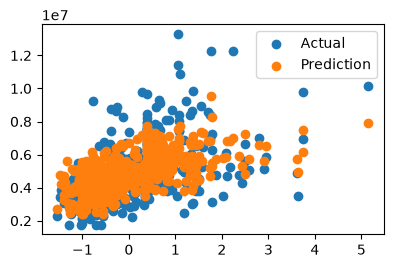



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.6514065355793901
Residual Sum of Squares (RSS) on Training set  ---> 528698230263940.56
Mean Squared Error (MSE) on Training set       ---> 1212610619871.423
Root Mean Squared Error (RMSE) on Training set ---> 1101186.0060277842

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.6768323425525846
Residual Sum of Squares (RSS) on Training set  ---> 124326933038541.89
Mean Squared Error (MSE) on Training set       ---> 1140614064573.7788
Root Mean Squared Error (RMSE) on Training set ---> 1067995.3485731008

--------------------Residual Plots--------------------


C:\Users\piyus\AppData\Local\Temp\ipykernel_18200\2030384463.py:46: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((Train_Y - pred1))


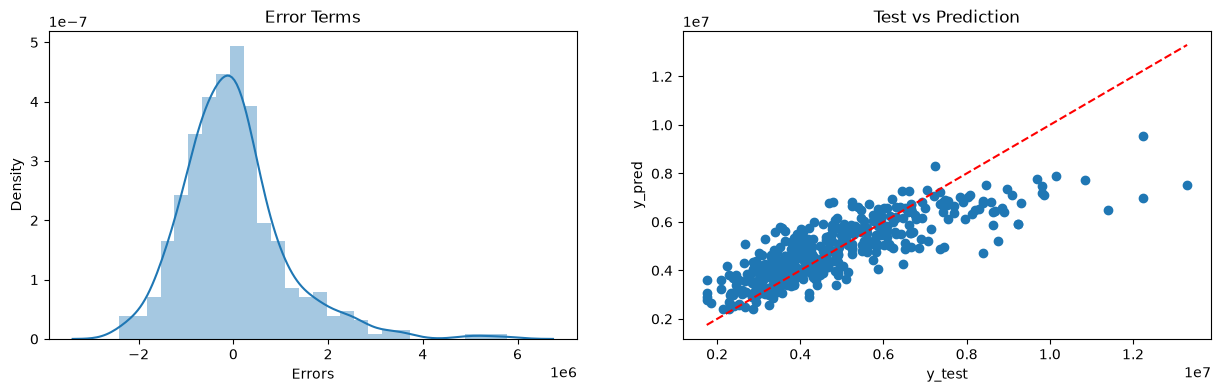

In [ ]:
#Creating a ElasticNet Regression model

from sklearn.linear_model import ElasticNet

ENR = ElasticNet().fit(Train_X_std,Train_Y)
pred1 = ENR.predict(Train_X_std)
pred2 = ENR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Elastic-Net Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(3, pred1, pred2)

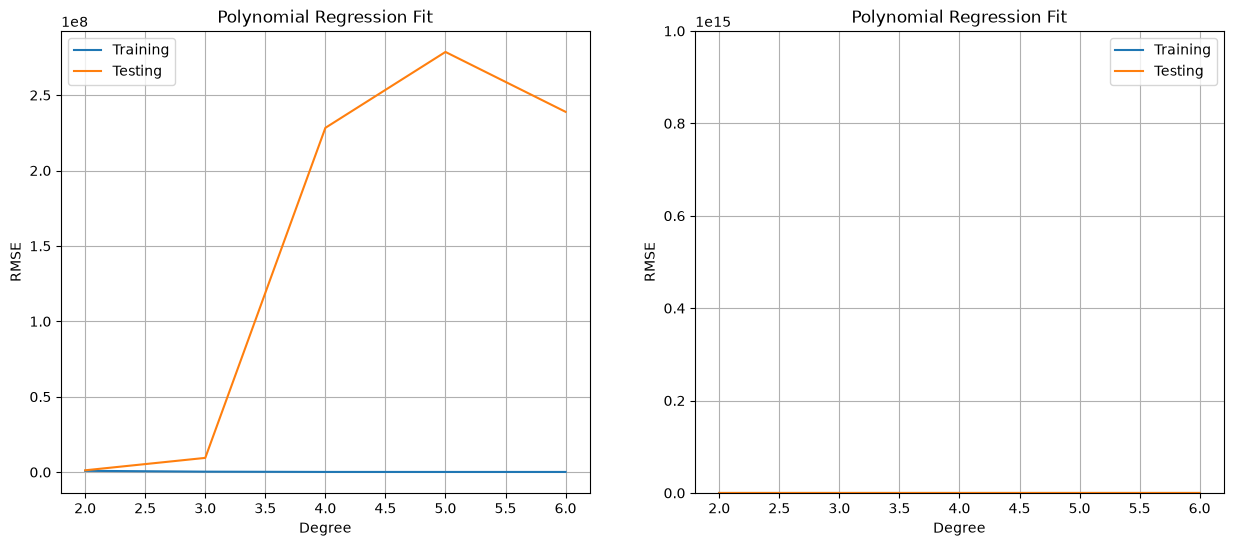

In [ ]:
#Checking polynomial regression performance on various degrees

Trr=[]; Tss=[]
n_degree=7

for i in range(2,n_degree):
    #print(f'{i} Degree')
    poly_reg = PolynomialFeatures(degree=i)
    X_poly = poly_reg.fit_transform(Train_X_std)
    X_poly1 = poly_reg.fit_transform(Test_X_std)
    LR = LinearRegression()
    LR.fit(X_poly, Train_Y)
    
    pred1 = LR.predict(X_poly)
    Trr.append(np.sqrt(mean_squared_error(Train_Y, pred1)))
    
    pred2 = LR.predict(X_poly1)
    Tss.append(np.sqrt(mean_squared_error(Test_Y, pred2)))

plt.figure(figsize=[15,6])
plt.subplot(1,2,1)
plt.plot(range(2,n_degree),Trr, label='Training')
plt.plot(range(2,n_degree),Tss, label='Testing')
#plt.plot([1,4],[1,4],'b--')
plt.title('Polynomial Regression Fit')
#plt.ylim([0,5])
plt.xlabel('Degree')
plt.ylabel('RMSE')
plt.grid()
plt.legend()


plt.subplot(1,2,2)
plt.plot(range(2,n_degree),Trr, label='Training')
plt.plot(range(2,n_degree),Tss, label='Testing')
plt.title('Polynomial Regression Fit')
plt.ylim([0,1e15])
plt.xlabel('Degree')
plt.ylabel('RMSE')
plt.grid()
plt.legend()

<<<----------------------------------- Evaluating Polynomial Regression Model ----------------------------------->>>

The Coeffecient of the Regresion Model was found to be  [ 523109.95193922   66116.64775464  571341.38886287  357741.5667533
  198127.53395452  145258.91156324  132749.64195469  193370.1889252
  387432.17922426  208377.3327589   255018.10885467  -50208.88614929
 -200559.54373648]
The Intercept of the Regresion Model was found to be  4795729.220183486


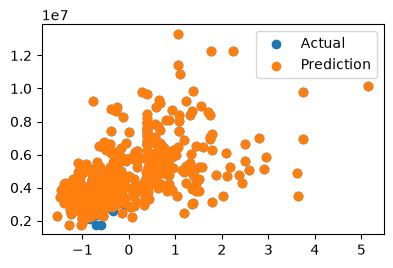



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.9961377244433224
Residual Sum of Squares (RSS) on Training set  ---> 5857764014598.088
Mean Squared Error (MSE) on Training set       ---> 13435238565.591946
Root Mean Squared Error (RMSE) on Training set ---> 115910.47651352292

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> -21993.74603861722
Residual Sum of Squares (RSS) on Training set  ---> 8.461673855428594e+18
Mean Squared Error (MSE) on Training set       ---> 7.763003537090453e+16
Root Mean Squared Error (RMSE) on Training set ---> 278621670.677111

--------------------Residual Plots--------------------


C:\Users\piyus\AppData\Local\Temp\ipykernel_18200\2030384463.py:46: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((Train_Y - pred1))


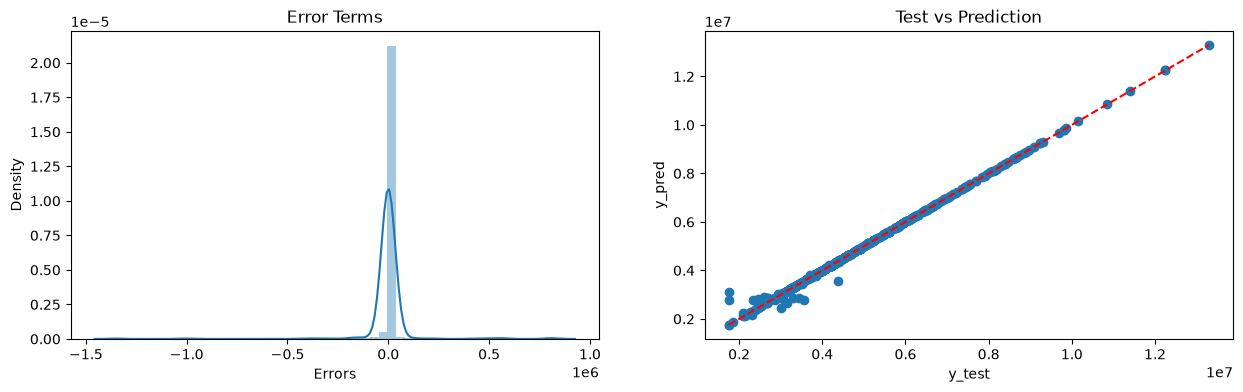

In [ ]:
#Using the 5th Order Polynomial Regression model (degree=5)

poly_reg = PolynomialFeatures(degree=5)
X_poly = poly_reg.fit_transform(Train_X_std)
X_poly1 = poly_reg.fit_transform(Test_X_std)
PR = LinearRegression()
PR.fit(X_poly, Train_Y)

pred1 = PR.predict(X_poly)
pred2 = PR.predict(X_poly1)

print('{}{}\033[1m Evaluating Polynomial Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(4, pred1, pred2)

In [ ]:
# Regression Models Results Evaluation

EMC = Model_Evaluation_Comparison_Matrix.copy()
EMC.index = ['Multiple Linear Regression (MLR)','Ridge Linear Regression (RLR)','Lasso Linear Regression (LLR)','Elastic-Net Regression (ENR)','Polynomial Regression (PNR)']
EMC

,Train-R2,Test-R2,Train-RSS,Test-RSS,Train-MSE,Test-MSE,Train-RMSE,Test-RMSE
Multiple Linear Regression (MLR),0.678179,0.680654,4.880936e+14,1.228567e+14,1.119481e+12,1.127126e+12,1.058055e+06,1.061662e+06
Ridge Linear Regression (RLR),0.678178,0.680811,4.880952e+14,1.227962e+14,1.119484e+12,1.126571e+12,1.058057e+06,1.061400e+06
Lasso Linear Regression (LLR),0.678179,0.680654,4.880936e+14,1.228567e+14,1.119481e+12,1.127125e+12,1.058055e+06,1.061662e+06
Elastic-Net Regression (ENR),0.651407,0.676832,5.286982e+14,1.243269e+14,1.212611e+12,1.140614e+12,1.101186e+06,1.067995e+06
Polynomial Regression (PNR),0.996138,-21993.746039,5.857764e+12,8.461674e+18,1.343524e+10,7.763004e+16,1.159105e+05,2.786217e+08


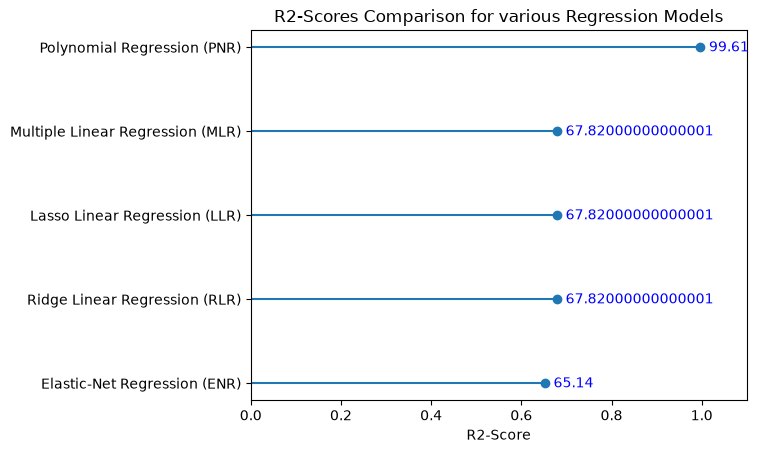

In [ ]:
# R2-Scores Comparison for different Regression Models

R2 = round(EMC['Train-R2'].sort_values(ascending=True),4)
plt.hlines(y=R2.index, xmin=0, xmax=R2.values)
plt.plot(R2.values, R2.index,'o')
plt.title('R2-Scores Comparison for various Regression Models')
plt.xlabel('R2-Score')
#plt.ylabel('Regression Models')
for i, v in enumerate(R2):
    plt.text(v+0.02, i-0.05, str(v*100), color='blue')
plt.xlim([0,1.1])
plt.show()

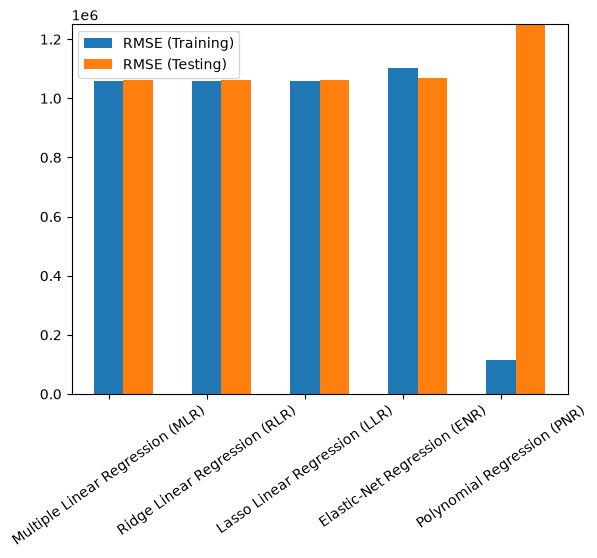

In [ ]:
# Root Mean SquaredError Comparison for different Regression Models

cc = Model_Evaluation_Comparison_Matrix.columns.values
s=5
#baxes = brokenaxes(ylims=((0,4),(524,532)))
#baxes.bar(np.arange(s), Model_Evaluation_Comparison_Matrix[cc[-2]].values, width=0.3, label='RMSE (Training)')
#baxes.bar(np.arange(s)+0.3, Model_Evaluation_Comparison_Matrix[cc[-1]].values, width=0.3, label='RMSE (Testing)')
# for index, value in enumerate(Model_Evaluation_Comparison_Matrix[cc[-2]].values):
#     plt.text(round(value,2), index, str(round(value,2)))
# for index, value in enumerate(Model_Evaluation_Comparison_Matrix[cc[-1]].values):
#     plt.text(round(value,2), index, str(round(value,2)))
plt.bar(np.arange(5), Model_Evaluation_Comparison_Matrix[cc[6]].values, width=0.3, label='RMSE (Training)')
plt.bar(np.arange(5)+0.3, Model_Evaluation_Comparison_Matrix[cc[7]].values, width=0.3, label='RMSE (Testing)')
plt.xticks(np.arange(5),EMC.index, rotation =35)
plt.legend()
plt.ylim([0,1.25e6])
plt.show()